## Load and preprocess audio data

### Subtask:
Load audio files from the specified directory, extracting features like MFCCs.


In [115]:
import os
import librosa
import numpy as np

dataset_paths = ['datasets/normal', 'datasets/delay']
features = []
labels = []

In [116]:
import audioread

# Select a sample audio file (replace with a path from your dataset)
sample_audio_path = os.path.join(dataset_paths[1], 'C_major_4', 'C_major_4-1.wav') # Using the first file of the first class as an example

# Open the audio file to get its info
try:
    with audioread.audio_open(sample_audio_path) as f:
        print(f"Audio File: {sample_audio_path}")
        print(f"  Duration: {f.duration} seconds")
        print(f"  Sample Rate: {f.samplerate}")
        print(f"  Channels: {f.channels}")

except audioread.NoBackendError:
    print("Could not open audio file. Please ensure you have necessary backend libraries installed (e.g., ffmpeg, gstreamer).")
except Exception as e:
    print(f"Error reading audio file info: {e}")

Audio File: datasets/delay/C_major_4/C_major_4-1.wav
  Duration: 2.5 seconds
  Sample Rate: 48000
  Channels: 1


**Reasoning**:
Iterate through the dataset directory, load audio files, extract CQT features, and store features and labels. Ensure consistent feature dimensions.



In [118]:
import warnings
from tqdm.notebook import tqdm
import numpy as np
import os # Import os for path manipulation
import librosa # Keep librosa import for potential future use or if file doesn't exist

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Define the path to the .npz file
save_dir = 'models'
save_path = os.path.join(save_dir, 'cqt_normal-delay-2s.npz')

print(f"Features and labels not found at {save_path}. Processing audio files...")

## Sample rate 48 khz * 2 seconds / 512 default hop size = 187.5
## Try 150 for 1.5 seconds
max_cqt_pad_len = 200

# pad -1 and +1 octave from root C4
fmin = librosa.note_to_hz('C3')

# 3 octaves in total
n_bins = 12 * 3

# default hop_length 512
hop_length = 512

def preprocess(cqt):
  if cqt.shape[1] < max_cqt_pad_len:
      pad_width = max_cqt_pad_len - cqt.shape[1]
      cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode='constant')
  else:
      cqt = cqt[:, :max_cqt_pad_len]
  return cqt

def extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len):
    """Extracts CQT features from an audio file."""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        cqt = librosa.cqt(y=y, sr=sr, fmin=fmin, n_bins=n_bins, bins_per_octave=12, hop_length=hop_length)
        cqt = np.abs(cqt)
        return preprocess(cqt)
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Check if the .npz file already exists
if os.path.exists(save_path):
    print(f"Loading features and labels from {save_path}")
    data = np.load(save_path)
    features = np.array([preprocess(f) for f in data['features']])
    labels = data['labels']
    print("Features and labels loaded successfully.")
else:
    features = []
    labels = []

    for dataset_path in tqdm(dataset_paths, desc=f"Processing dataset"):
        for class_name in tqdm(os.listdir(dataset_path), desc="Processing classes"):
            class_path = os.path.join(dataset_path, class_name)
            if os.path.isdir(class_path):
                for audio_file in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
                    audio_path = os.path.join(class_path, audio_file)
                    if os.path.isfile(audio_path):
                        cqt_features = extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len)
                        if cqt_features is not None:
                            features.append(cqt_features)
                            labels.append(class_name)

    features = np.array(features)
    labels = np.array(labels)

    print(f"Shape of CQT features: {features.shape}")
    print(f"Shape of CQT labels: {labels.shape}")

    # Create the directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    # Save the features and labels
    np.savez(save_path, features=features, labels=labels)

    print(f"Features and labels saved to {save_path}")

Features and labels not found at models/cqt_normal-delay-2s.npz. Processing audio files...
Loading features and labels from models/cqt_normal-delay-2s.npz
Features and labels loaded successfully.


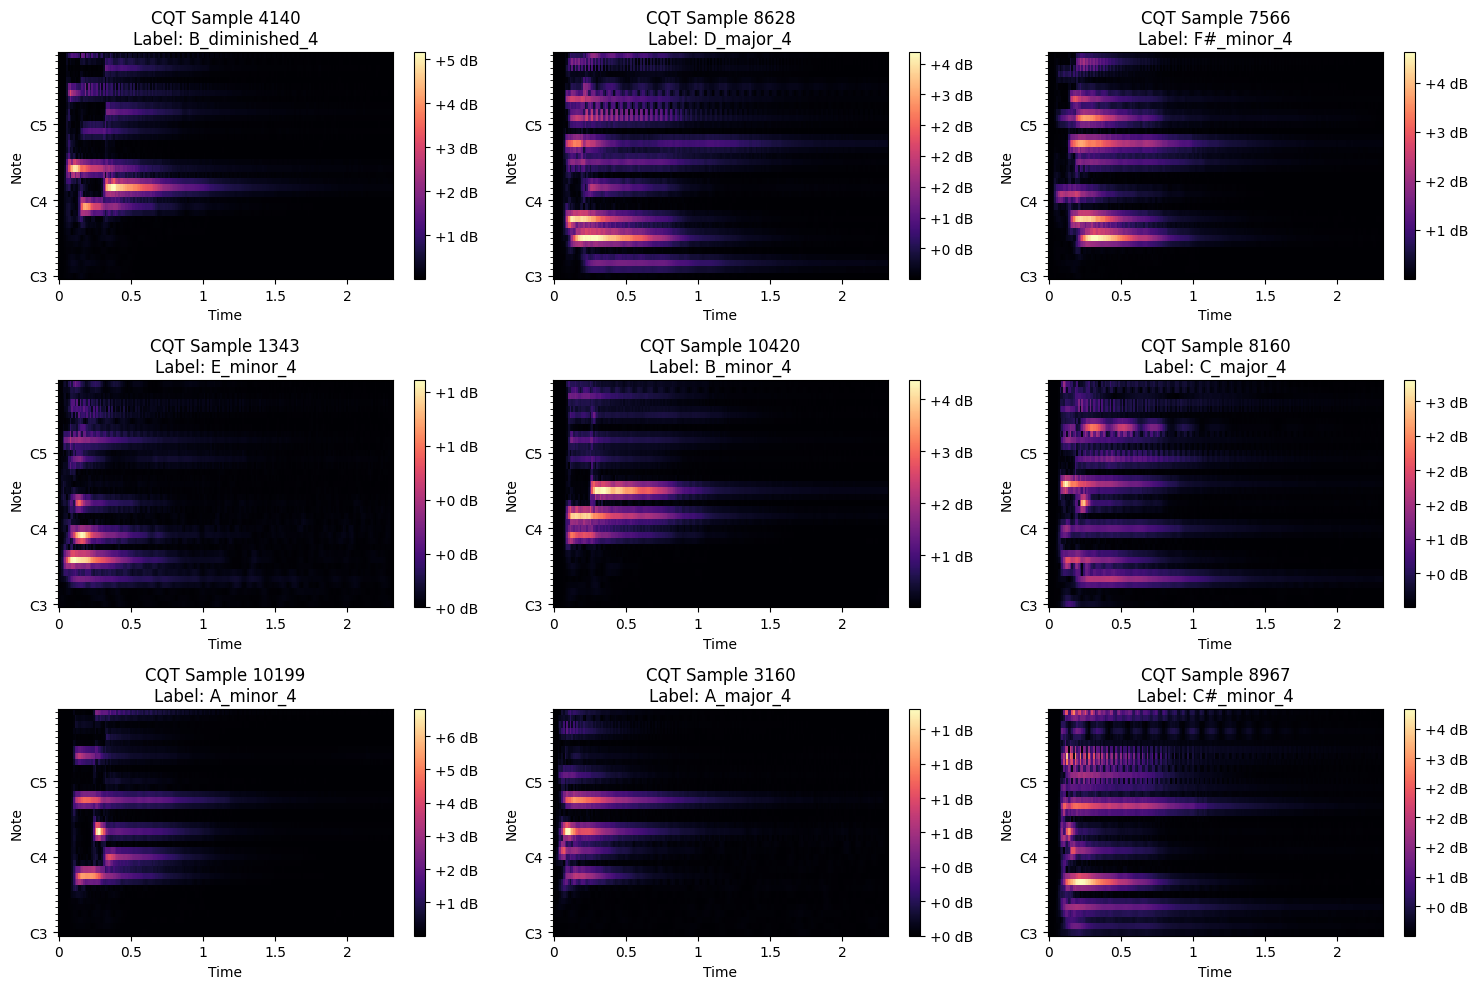

In [119]:
import random
import matplotlib.pyplot as plt
import librosa.display

# Select 9 random indices
random_indices = random.sample(range(len(features)), min(9, len(features)))

# Plot the CQT data for the selected samples
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    # Assuming 'sr' is still available from the previous processing step
    try:
        # Explicitly pass fmin to specshow
        librosa.display.specshow(features[idx], x_axis='time', y_axis='cqt_note', sr=sr, bins_per_octave=12, fmin=fmin, hop_length=hop_length/2)
    except NameError:
        # Handle case where sr is not defined (e.g., if the previous cell failed)
        librosa.display.specshow(features[idx], x_axis='time', y_axis='cqt_note', bins_per_octave=12, fmin=fmin, hop_length=hop_length/2) # Plot without sr

    plt.colorbar(format='%+2.0f dB')
    plt.title(f'CQT Sample {idx+1}\nLabel: {labels[idx]}')

plt.tight_layout()
plt.show()

## Split data

### Subtask:
Split the dataset into training and testing sets.

**Reasoning**:
Split the features and labels into training and testing sets using `train_test_split` from `sklearn.model_selection`.

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, categorical_labels, test_size=0.1, random_state=42, stratify=categorical_labels)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Length of training set: {len(X_train)}")
print(f"Length of testing set: {len(X_test)}")

Shape of X_train: (9720, 36, 200)
Shape of X_test: (1080, 36, 200)
Shape of y_train: (9720, 36)
Shape of y_test: (1080, 36)
Length of training set: 9720
Length of testing set: 1080


## Build CNN model

### Subtask:
Define and compile a CNN model architecture suitable for audio classification.

**Reasoning**:
Define a sequential CNN model using `tensorflow.keras.models.Sequential`. Add convolutional, pooling, and dense layers. Compile the model with an appropriate optimizer, loss function, and metrics.

In [121]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Reshape

# Get input shape and number of classes
input_shape = (features.shape[1], features.shape[2], 1) # Add channel dimension based on original features shape
num_classes = y_train.shape[1]

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    # Conv2D(128, (3, 3), activation='relu'),
    # MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 34, 198, 32)       320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 17, 99, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 15, 97, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 7, 48, 64)         0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 21504)             0         
                                                                 
 dense_2 (Dense)             (None, 64)               

## Train model

### Subtask:
Train the CNN model using the training data.

**Reasoning**:
Train the CNN model using the `fit` method, providing the training data and specifying the number of epochs and batch size.

In [122]:
# Train the model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1)

Epoch 1/30


2026-01-07 21:37:47.995058: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 251942400 exceeds 10% of free system memory.


274/274 [==============================] - 17s 61ms/step - loss: 1.5541 - accuracy: 0.5472 - val_loss: 0.0849 - val_accuracy: 0.9990
Epoch 2/30
274/274 [==============================] - 16s 60ms/step - loss: 0.4805 - accuracy: 0.8395 - val_loss: 0.0126 - val_accuracy: 1.0000
Epoch 3/30
274/274 [==============================] - 16s 57ms/step - loss: 0.3746 - accuracy: 0.8660 - val_loss: 0.0052 - val_accuracy: 0.9990
Epoch 4/30
274/274 [==============================] - 16s 58ms/step - loss: 0.3088 - accuracy: 0.8852 - val_loss: 0.0024 - val_accuracy: 1.0000
Epoch 5/30
274/274 [==============================] - 16s 60ms/step - loss: 0.2759 - accuracy: 0.8955 - val_loss: 0.0013 - val_accuracy: 1.0000
Epoch 6/30
274/274 [==============================] - 16s 59ms/step - loss: 0.2773 - accuracy: 0.8930 - val_loss: 4.7983e-04 - val_accuracy: 1.0000
Epoch 7/30
274/274 [==============================] - 16s 59ms/step - loss: 0.2455 - accuracy: 0.9102 - val_loss: 2.3379e-04 - val_accuracy: 1.

## Plot training history

### Subtask:
Visualize the training and validation accuracy and loss over epochs.

**Reasoning**:
Plot the training and validation accuracy and loss from the `history` object to evaluate the model's performance during training.

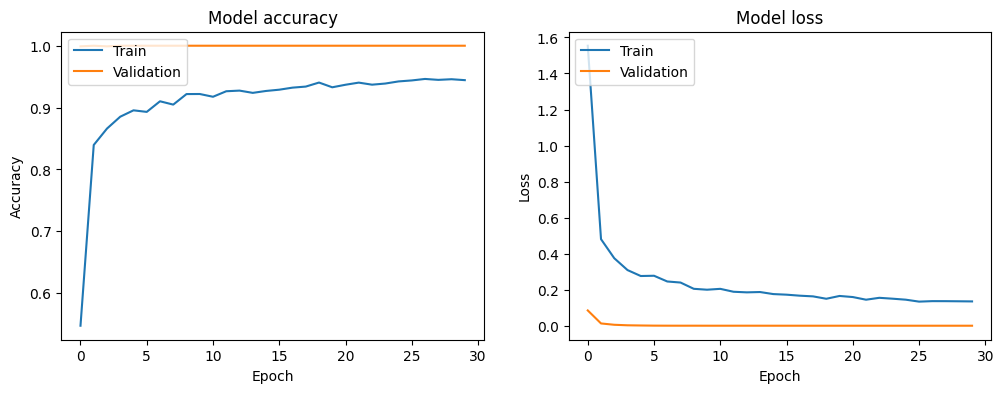

In [123]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# Confusion Matrix

34/34 [==============================] - 0s 11ms/step


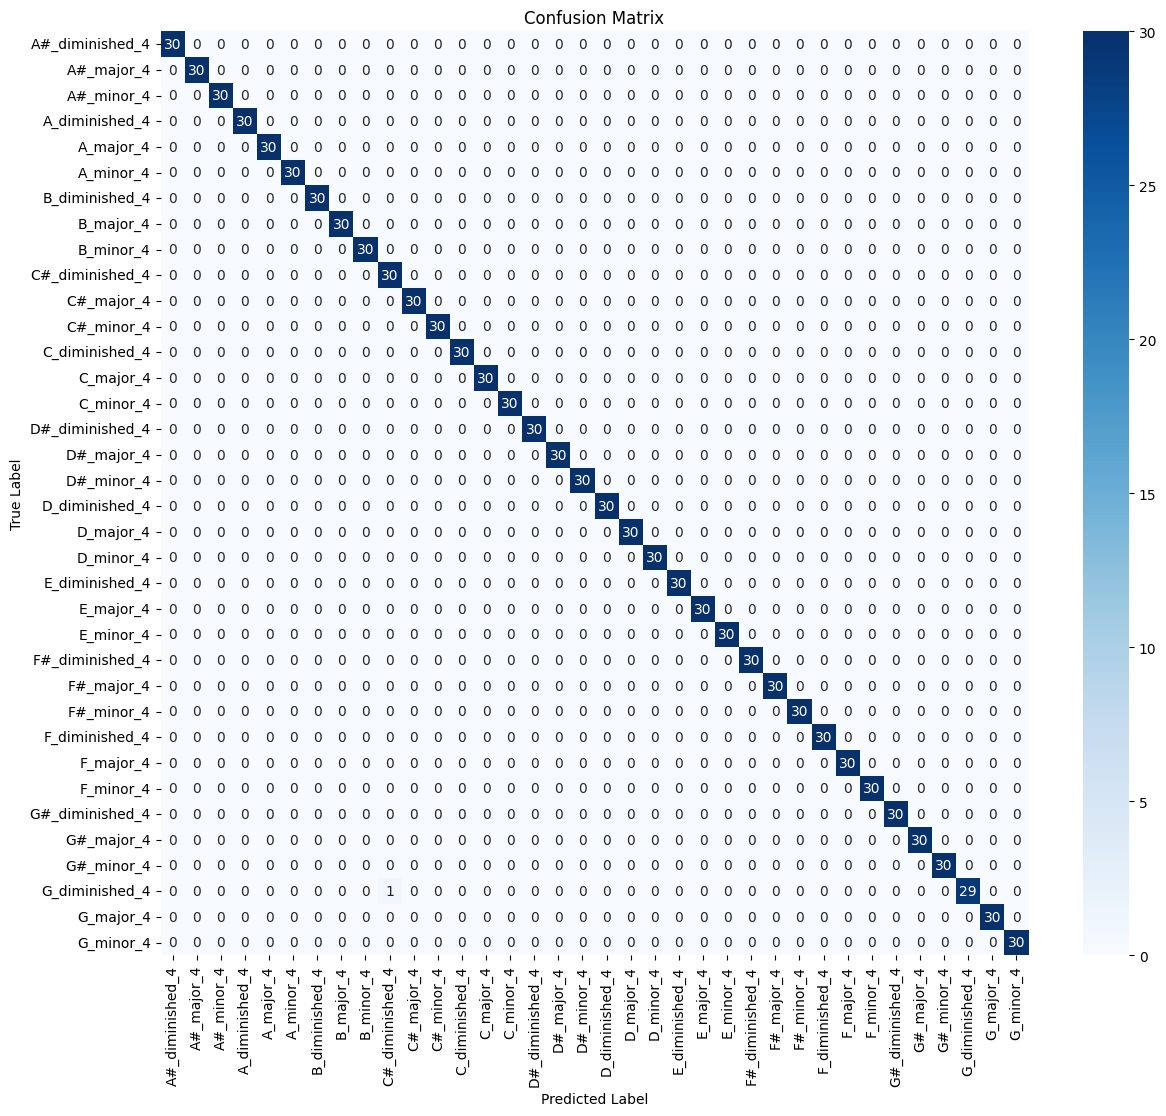

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Get class labels from the label encoder
class_labels = label_encoder.classes_

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [125]:
from sklearn.metrics import classification_report

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# Generate classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels)
print("Classification Report:\n", report)

Test Accuracy: 0.9991
Test Loss: 0.0047
Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        30
     A#_major_4       1.00      1.00      1.00        30
     A#_minor_4       1.00      1.00      1.00        30
 A_diminished_4       1.00      1.00      1.00        30
      A_major_4       1.00      1.00      1.00        30
      A_minor_4       1.00      1.00      1.00        30
 B_diminished_4       1.00      1.00      1.00        30
      B_major_4       1.00      1.00      1.00        30
      B_minor_4       1.00      1.00      1.00        30
C#_diminished_4       0.97      1.00      0.98        30
     C#_major_4       1.00      1.00      1.00        30
     C#_minor_4       1.00      1.00      1.00        30
 C_diminished_4       1.00      1.00      1.00        30
      C_major_4       1.00      1.00      1.00        30
      C_minor_4       1.00      1.00      1.00        30
D#_diminished_4       1

# Save Model

In [126]:
# Save the model to Google Drive
model_save_path = 'models/CNN_normal-delay'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

INFO:tensorflow:Assets written to: models/CNN_normal-delay/assets


INFO:tensorflow:Assets written to: models/CNN_normal-delay/assets


Model saved to models/CNN_normal-delay


In [146]:
import tensorflowjs as tfjs

# Disable variable initialization
from keras.backend import manual_variable_initialization
manual_variable_initialization(True)

# Define the path to save the TensorFlow.js model
tfjs_save_path = model_save_path

# Convert and save the model in TensorFlow.js format
tfjs.converters.save_keras_model(model, tfjs_save_path)

print(f"TensorFlow.js model saved to {tfjs_save_path}")

TensorFlow.js model saved to models/CNN_normal-delay


In [138]:
# Select a random sample from the test set
random_index = random.randint(0, len(X_test) - 1)
sample_features = X_test[random_index]
sample_actual_label_categorical = y_test[random_index]

# Reshape the sample features for prediction (add batch and channel dimensions)
sample_features_reshaped = np.expand_dims(sample_features, axis=0)
sample_features_reshaped = np.expand_dims(sample_features_reshaped, axis=-1)

# Make a prediction
predictions = model.predict(sample_features_reshaped)
predicted_class_index = np.argmax(predictions)

# Decode the actual and predicted labels
actual_class_index = np.argmax(sample_actual_label_categorical)
actual_class_label = label_encoder.inverse_transform([actual_class_index])[0]
predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]

print(f"Actual Label: {actual_class_label}")
print(f"Predicted Label: {predicted_class_label}")

1/1 [==============================] - 0s 17ms/step
Actual Label: D#_minor_4
Predicted Label: D#_minor_4


## Test Model

In [145]:
import random
import tensorflow as tf
import numpy as np

# Load the saved Keras model
model_path = model_save_path # Or .h5
loaded_model = tf.keras.models.load_model(model_path)

# Select a random sample from the test set
random_index = random.randint(0, len(X_test) - 1)
sample_features = X_test[random_index]
sample_actual_label_categorical = y_test[random_index]

# Reshape the sample features for prediction (add batch and channel dimensions)
sample_features_reshaped = np.expand_dims(sample_features, axis=0)
sample_features_reshaped = np.expand_dims(sample_features_reshaped, axis=-1)

# Make a prediction
predictions = loaded_model.predict(sample_features_reshaped)
predicted_class_index = np.argmax(predictions)

# Decode the actual and predicted labels
actual_class_index = np.argmax(sample_actual_label_categorical)
actual_class_label = label_encoder.inverse_transform([actual_class_index])[0]
predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]

print(f"Actual Label: {actual_class_label}")
print(f"Predicted Label: {predicted_class_label}")

1/1 [==============================] - 0s 49ms/step
Actual Label: D#_minor_4
Predicted Label: D#_minor_4
